# _Máquinas Delirantes - APS3_
# Luizettp

### Importando Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from pathlib import Path

# Obviamente o Codex evoluiu minha entrega: parece que comando uma criatura mística incompreensível e de poder infinito.
# Sou obrigado a admitir que essa ficou minha APS mais bela graças à entidade-estatística, pelo menos visualmente. Infelizmente, gostei do resultado.

# Porém, verá que gastei bom tempo comentando e visando compreender tudo (ou quase), tentando argumentar que sou eu o maestro dessa orquestra e esquecer que, 
# em muitos concertos que fui, já me perguntei se a sinfonia realmente precisava de um.

# Imagino que só utilizei funções vistas na aula, já que reciclei códigos meus delas em muitas partes.

_______________________
## Questão 1

### Devemos encontrar o valor, em dólares, de cada conjunto de moedas. Para isso, segmentamos cada moeda pelo fundo branco, pegamos seu contorno e classificamos por tamanho. O centavo é facilmente indentificável considerando que é cobre.
![Fig1_Moedas1.png](Figuras_APS3/Fig1_Moedas1.png)
![Fig1_Moedas2.png](Figuras_APS3/Fig1_Moedas2.png)
![Fig1_Moedas3.png](Figuras_APS3/Fig1_Moedas3.png)
![Fig1_Moedas4.png](Figuras_APS3/Fig1_Moedas4.png)


 Fig1_Moedas1.png
Moedas encontradas = 7
penny   = 2 -> 1 centavo
nickel  = 1 -> 5 centavos
dime    = 1 -> 10 centavos
quarter = 3 -> 25 centavos
Total   = US$ 0.92

 Fig1_Moedas2.png
Moedas encontradas = 7
penny   = 0 -> 1 centavo
nickel  = 3 -> 5 centavos
dime    = 3 -> 10 centavos
quarter = 1 -> 25 centavos
Total   = US$ 0.70

 Fig1_Moedas3.png
Moedas encontradas = 8
penny   = 1 -> 1 centavo
nickel  = 4 -> 5 centavos
dime    = 2 -> 10 centavos
quarter = 1 -> 25 centavos
Total   = US$ 0.66

 Fig1_Moedas4.png
Moedas encontradas = 8
penny   = 3 -> 1 centavo
nickel  = 2 -> 5 centavos
dime    = 1 -> 10 centavos
quarter = 2 -> 25 centavos
Total   = US$ 0.73


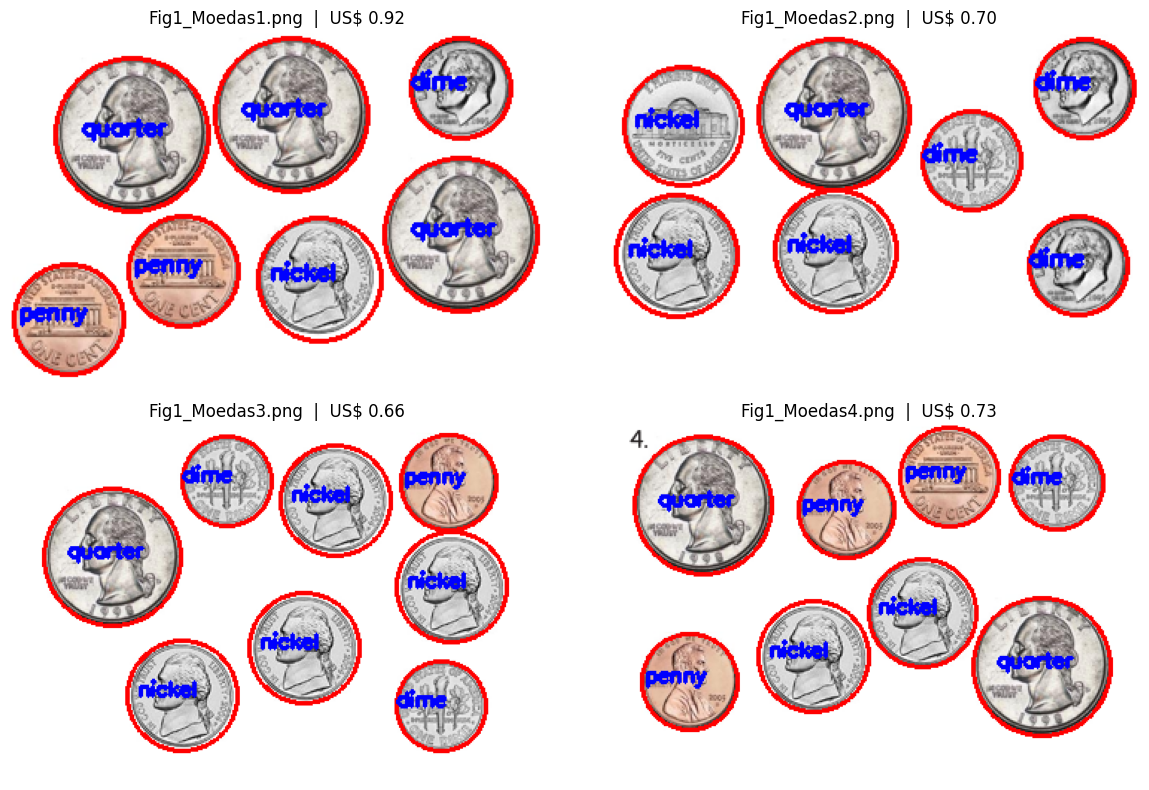

In [3]:
# ============================================================
# Exercício 1
# Valor de cada conjunto de moedas em USD
# ============================================================


# Valores das moedas americanas
Coins = {
    "penny":   0.01,
    "nickel":  0.05,
    "dime":    0.10,
    "quarter": 0.25
}

Moedas = {
    "penny":   "1 centavo",
    "nickel":  "5 centavos",
    "dime":    "10 centavos",
    "quarter": "25 centavos"
}


# ============================================================
# 1) Função para ler imagem e tratar o canal alfa, quando existe
# ============================================================
def LerImagemRGB(caminho):

    img = cv2.imread(str(caminho), cv2.IMREAD_UNCHANGED)

    if img is None:
        raise RuntimeError("Não consegui abrir a imagem: " + str(caminho))

    # Algumas imagens podem vir em RGBA.
    # RGB são as três cores normais: vermelho, verde e azul.
    # O A é o canal alfa, que não é exatamente uma cor: ele indica transparência.
    #
    # Exemplo intuitivo:
    # - alfa = 255  -> pixel totalmente visível
    # - alfa = 0    -> pixel totalmente transparente
    # - alfa no meio -> mistura entre a imagem e o fundo
    #
    # Como vemos as moedas em fundo branco, colocamos qualquer
    # parte transparente sobre um fundo branco. Assim a imagem vira uma foto
    # comum, com apenas BGR/RGB.
    if len(img.shape) == 3 and img.shape[2] == 4:

        # Se entrou aqui, a imagem tem 4 canais.
        # Pegamos os 3 primeiros canais como cor da moeda/fundo.
        bgr = img[:, :, :3].astype(np.float32)

        # Pegamos o quarto canal, o alfa, e dividimos por 255 para virar
        # um peso entre 0 e 1. 
        alpha = img[:, :, 3:4].astype(np.float32) / 255.0

        # Criamos uma imagem toda branca, do mesmo tamanho da original.
        # np.ones_like cria uma matriz igual no formato, mas preenchida com 1.
        # Multiplicando por 255, ela vira branco puro.
        fundo = np.ones_like(bgr, dtype=np.float32) * 255

        # Mistura final:
        # onde o alfa é alto, aparece mais a moeda;
        # onde o alfa é baixo, aparece mais o fundo branco.
        img_bgr = (bgr * alpha + fundo * (1 - alpha)).astype(np.uint8)
    else:

        # Se caiu no else, a imagem já veio sem transparência.
        img_bgr = img.copy()

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    return img_rgb


# ============================================================
# 2) Classificação da moeda
# ============================================================
def ClassificaMoeda(raio, media_rgb):

    R, G, B = media_rgb

    # O penny tem cor cobre: vermelho maior que verde e azul.
    if (R - G > 20) and (R - B > 35):
        return "penny"

    # Para as moedas prateadas, o tamanho separa bem nas figuras.
    if raio >= 43:
        return "quarter"

    if raio >= 35:
        return "nickel"

    return "dime"


# ============================================================
# 3) Função principal: segmentar, achar contornos e somar valores
# ============================================================
def SomadordeCoins(caminho):

    img_rgb = LerImagemRGB(caminho)
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    # Segmentação pelo fundo branco.
    # Queremos criar uma imagem binária, isto é, uma imagem só com 0 e 255.
    # A ideia é:
    # - 0   = fundo
    # - 255 = alguma coisa que não é fundo, provavelmente moeda
    #
    # np.zeros_like(img_gray) cria uma matriz do mesmo tamanho da imagem cinza,

    img_bin = np.zeros_like(img_gray, dtype=np.uint8)

    # Como o fundo é branco, ele tem intensidade perto de 255.
    # Então, se o pixel tem cinza menor que 250, ele já não é branco puro.
    # Logo, marcamos esse pixel como objeto na máscara.
    img_bin[img_gray < 250] = 255

    # Abertura = erosão seguida de dilatação.
    # Pensando visualmente:
    # - a erosão tira pontos pequenos e afina um pouco os objetos;
    # - a dilatação devolve quase o tamanho original do que sobrou.
    #
    # Limpeza preventiva porque podemos.
    # Primeiro erode para tirar pontos pequenos, depois dilate para devolver o tamanho.
    
    kernel = np.ones((2, 2), np.uint8)
    img_bin = cv2.erode(img_bin, kernel, iterations=1)
    img_bin = cv2.dilate(img_bin, kernel, iterations=1)

    # Agora procuramos os contornos externos nessa imagem binária.
    # Um contorno é a borda fechada de uma região branca.
    # Idealmente, cada moeda vira um contorno.
    # Textos e números também podem virar contornos, por isso filtramos depois.
    contornos, _ = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    moedas = []

    for contorno in contornos:

        area = cv2.contourArea(contorno)

        # Primeiro filtro: área.
        if area < 2000:
            continue

        # Aqui calculamos o menor círculo que consegue envolver o contorno.
        # O resultado vem como:
        # - (x, y): centro aproximado da moeda
        # - raio: tamanho aproximado da moeda
        # área pequena sai no filtro acima, e formato pouco circular sai abaixo.
        # O raio também é usado depois para diferenciarmos quarter, nickel e dime.
        (x, y), raio = cv2.minEnclosingCircle(contorno)

        # Circularidade compara a área do contorno com a área do círculo em volta.
        # Se o objeto for uma moeda, ele é quase redondo, então essa razão fica alta.
        # Achei bem inteligente essa solução, honestamente.
        circularidade = area / (np.pi * raio * raio)

        # A moeda deve ser aproximadamente circular.
        if circularidade < 0.70:
            continue

        mascara_moeda = np.zeros_like(img_gray, dtype=np.uint8)
        cv2.drawContours(mascara_moeda, [contorno], -1, 255, -1)

        media_rgb = cv2.mean(img_rgb, mask=mascara_moeda)[:3]
        tipo = ClassificaMoeda(raio, media_rgb)

        moedas.append({
            "x": x,
            "y": y,
            "raio": raio,
            "area": area,
            "tipo": tipo,
            "valor": Coins[tipo]
        })

    moedas = sorted(moedas, key=lambda m: (m["y"], m["x"]))
    total = sum(m["valor"] for m in moedas)

    return img_rgb, img_bin, moedas, total


# ============================================================
# 4) Rodando nas quatro imagens do enunciado
# ============================================================
caminhos = [
    Path("Figuras_APS3/Fig1_Moedas1.png"),
    Path("Figuras_APS3/Fig1_Moedas2.png"),
    Path("Figuras_APS3/Fig1_Moedas3.png"),
    Path("Figuras_APS3/Fig1_Moedas4.png") ]

plt.figure(figsize=(12, 8))

for i, caminho in enumerate(caminhos):

    img_rgb, img_bin, moedas, total = SomadordeCoins(caminho)
    img_saida = img_rgb.copy()

    contagem = {
        "penny":   0,
        "nickel":  0,
        "dime":    0,
        "quarter": 0
    }

    for moeda in moedas:
        contagem[moeda["tipo"]] += 1

        centro = (int(moeda["x"]), int(moeda["y"]))
        raio = int(moeda["raio"])

        cv2.circle(img_saida, centro, raio, (255, 0, 0), 2)
        cv2.putText(img_saida, moeda["tipo"], (centro[0] - 30, centro[1]),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 2)

    print("\n", caminho.name)
    print("Moedas encontradas =", len(moedas))
    print("penny   =", contagem["penny"],   "->", Moedas["penny"])
    print("nickel  =", contagem["nickel"],  "->", Moedas["nickel"])
    print("dime    =", contagem["dime"],    "->", Moedas["dime"])
    print("quarter =", contagem["quarter"], "->", Moedas["quarter"])
    print("Total   = US$ %.2f" % total)

    plt.subplot(2, 2, i + 1)
    plt.imshow(img_saida)
    plt.title(caminho.name + "  |  US$ %.2f" % total)
    plt.axis("off")

plt.tight_layout()
plt.show()

**______________________________________________________________________________________________________________________________**

## Questão 2

### Devemos definir o time vencedor no curling e a pontuação. A lógica é a regra do jogo: primeiro medimos a distância de cada peça até o centro. O time da peça mais próxima vence, e sua pontuação é a quantidade de peças desse mesmo time que estão mais próximas do centro do que a melhor peça adversária. Nas figuras, o time que acompanha o vermelho aparece em amarelo, então chamamos ele de amarelo para não brigar com a imagem.

![Fig2_Curling1.bmp](Figuras_APS3/Fig2_Curling1.bmp)
![Fig2_Curling2.bmp](Figuras_APS3/Fig2_Curling2.bmp)
![Fig2_Curling3.bmp](Figuras_APS3/Fig2_Curling3.bmp)


 Fig2_Curling1.bmp
Peças encontradas = 6
vermelho -> distância 31.5
vermelho -> distância 42.7
amarelo -> distância 76.9
vermelho -> distância 112.9
amarelo -> distância 152.3
vermelho -> distância 189.5
Vencedor = vermelho
Pontuação = 2

 Fig2_Curling2.bmp
Peças encontradas = 4
amarelo -> distância 58.5
vermelho -> distância 88.4
vermelho -> distância 120.3
vermelho -> distância 173.4
Vencedor = amarelo
Pontuação = 1

 Fig2_Curling3.bmp
Peças encontradas = 3
amarelo -> distância 168.5
vermelho -> distância 171.9
amarelo -> distância 181.3
Vencedor = amarelo
Pontuação = 1


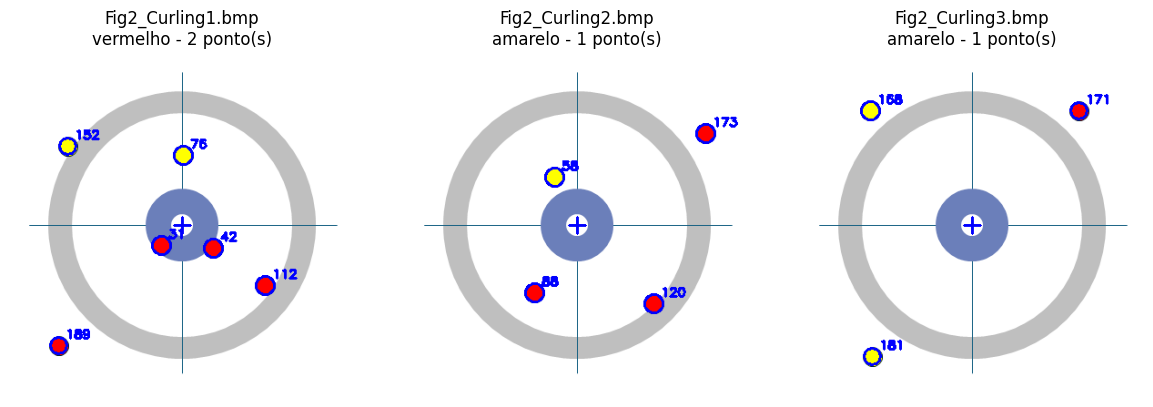

In [5]:
# ============================================================
# Exercício 2
# Definir o vencedor e a pontuação do curling
# ============================================================


# ============================================================
# 1) Função para detectar as peças vermelhas e amarelas
# ============================================================
def DetectaPecasCurling(img_rgb):

    h, w, _ = img_rgb.shape

    # O alvo está desenhado no meio da figura.
    # Então o centro de pontuação é o centro da própria imagem.
    centro_alvo = np.array([w / 2, h / 2], dtype=float)

    # Separamos os canais para fazer limiares simples por cor.
    # Isso segue a mesma ideia de sempre, inclusive do ex. anterior: olhar os canais e criar uma máscara.
    R = img_rgb[:, :, 0]
    G = img_rgb[:, :, 1]
    B = img_rgb[:, :, 2]

    # Máscara das peças vermelhas:
    # muito vermelho, pouco verde e pouco azul.
    mascara_vermelho = np.zeros_like(R, dtype=np.uint8)
    mascara_vermelho[(R > 180) & (G < 80) & (B < 80)] = 255

    # Máscara das peças amarelas:
    # muito vermelho + muito verde + pouco azul.
    mascara_amarelo = np.zeros_like(R, dtype=np.uint8)
    mascara_amarelo[(R > 180) & (G > 180) & (B < 80)] = 255

    mascaras = {
        "vermelho": mascara_vermelho,
        "amarelo": mascara_amarelo
    }

    pecas = []

    for cor in mascaras:

        mascara = mascaras[cor]

        # Pequena limpeza para tirar pixels soltos. Só porque eu posso mesmo.
        # Primeiro erode, depois dilate. Como as peças são bolinhas grandes, elas sobrevivem.
        kernel = np.ones((3, 3), np.uint8)
        mascara = cv2.erode(mascara, kernel, iterations=1)
        mascara = cv2.dilate(mascara, kernel, iterations=1)

        # Procuramos os contornos da máscara daquela cor.
        contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for contorno in contornos:

            area = cv2.contourArea(contorno)

            # Filtro de área 
            if area < 100:
                continue

            # Colocamos um círculo em volta do contorno.
            # O centro desse círculo é a posição aproximada da peça.
            (x, y), raio = cv2.minEnclosingCircle(contorno)

            circularidade = area / (np.pi * raio * raio)

            # A peça deve ser aproximadamente circular.
            if circularidade < 0.60:
                continue

            # Distância euclidiana até o centro do alvo.
            # Pitágoras, óbvio: sqrt(dx² + dy²).
            distancia = np.sqrt((x - centro_alvo[0])**2 + (y - centro_alvo[1])**2)

            pecas.append({
                "cor": cor,
                "x": x,
                "y": y,
                "raio": raio,
                "area": area,
                "distancia": distancia
            })

    # Ordenamos da peça mais próxima para a mais distante.
    pecas = sorted(pecas, key=lambda p: p["distancia"])

    return pecas, centro_alvo


# ============================================================
# 2) Função para calcular vencedor e pontos
# ============================================================
def CalculaPontuacaoCurling(pecas):

    # A peça mais próxima do centro define o time vencedor.
    vencedor = pecas[0]["cor"]

    # Agora precisamos achar a melhor peça adversária.
    # A pontuação do vencedor é quantas peças dele estão antes dessa peça adversária. (Acho....)
    dist_adversario = None

    for peca in pecas:
        if peca["cor"] != vencedor:
            dist_adversario = peca["distancia"]
            break

    # Se só existir um time na imagem, todas as peças dele pontuam.
    if dist_adversario is None:
        dist_adversario = 999999

    pontos = 0

    for peca in pecas:
        if peca["cor"] == vencedor and peca["distancia"] < dist_adversario:
            pontos += 1

    return vencedor, pontos


# ============================================================
# 3) Rodando nas três figuras
# ============================================================
caminhos_curling = [
    Path("Figuras_APS3/Fig2_Curling1.bmp"),
    Path("Figuras_APS3/Fig2_Curling2.bmp"),
    Path("Figuras_APS3/Fig2_Curling3.bmp")
]

plt.figure(figsize=(12, 4))

for i, caminho in enumerate(caminhos_curling):

    img_bgr = cv2.imread(str(caminho))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    pecas, centro_alvo = DetectaPecasCurling(img_rgb)
    vencedor, pontos = CalculaPontuacaoCurling(pecas)

    img_saida = img_rgb.copy()

    # Marcamos o centro usado na conta.
    cx = int(centro_alvo[0])
    cy = int(centro_alvo[1])
    cv2.drawMarker(img_saida, (cx, cy), (0, 0, 255), cv2.MARKER_CROSS, 18, 2)

    for peca in pecas:

        centro_peca = (int(peca["x"]), int(peca["y"]))
        raio = int(peca["raio"])

        # Contorno azul para enxergarmos quais peças foram detectadas.
        cv2.circle(img_saida, centro_peca, raio, (0, 0, 255), 2)

        # Escrevemos a distância arredondada, pois é ela que manda na pontuação.
        texto = str(int(peca["distancia"]))
        cv2.putText(img_saida, texto, (centro_peca[0] + 8, centro_peca[1] - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 2)

    print("\n", caminho.name)
    print("Peças encontradas =", len(pecas))

    for peca in pecas:
        print(peca["cor"], "-> distância %.1f" % peca["distancia"])

    print("Vencedor =", vencedor)
    print("Pontuação =", pontos)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img_saida)
    plt.title(caminho.name + "\n" + vencedor + " - " + str(pontos) + " ponto(s)")
    plt.axis("off")

plt.tight_layout()
plt.show()

**______________________________________________________________________________________________________________________________**

## Questão 3

### Devemos dizer se cada lata está amassada. A ideia é olhar para o contorno externo: uma lata vista de cima deve parecer uma elipse bem lisa. Quando existe amassado, a borda faz uma entrada ou saliência e deixa de seguir essa elipse. Então segmentamos a lata do fundo escuro, pegamos o maior contorno e medimos o erro entre esse contorno real e a elipse ajustada nele.

<img src="Figuras_APS3/Fig3_lata1.png" width="260">
<img src="Figuras_APS3/Fig3_lata2.png" width="260">
<img src="Figuras_APS3/Fig3_lata3.png" width="260">
<img src="Figuras_APS3/Fig3_lata4.png" width="260">
<img src="Figuras_APS3/Fig3_lata5.png" width="260">


 Fig3_lata1.png
Erro em relação à elipse = 0.0045
Status = normal

 Fig3_lata2.png
Erro em relação à elipse = 0.0148
Status = amassada

 Fig3_lata3.png
Erro em relação à elipse = 0.0049
Status = normal

 Fig3_lata4.png
Erro em relação à elipse = 0.0104
Status = amassada

 Fig3_lata5.png
Erro em relação à elipse = 0.0109
Status = amassada


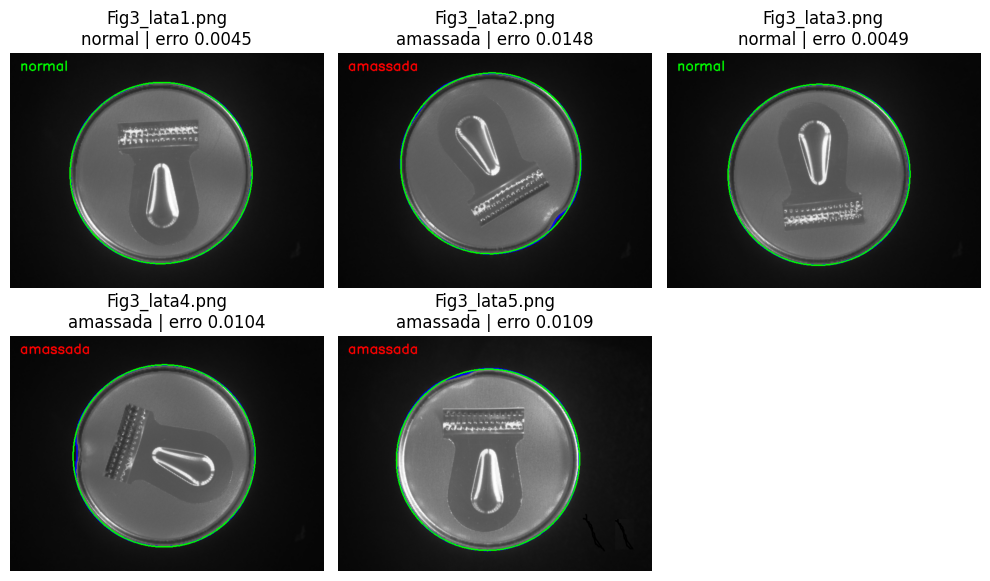

In [6]:
# ============================================================
# Exercício 3
# Verificar se as latas estão amassadas
# ============================================================


# Limiar escolhido olhando a separação entre latas boas e amassadas.
# Nas latas boas o erro ficou perto de 0.005.
# Nas amassadas o erro ficou maior, perto de 0.010 ou mais.
LIMIAR_ERRO_ELIPSE = 0.008


# ============================================================
# 1) Função para ler a lata em tons de cinza
# ============================================================
def LerLataCinza(caminho):

    img = cv2.imread(str(caminho), cv2.IMREAD_UNCHANGED)

    if img is None:
        raise RuntimeError("Não consegui abrir a imagem: " + str(caminho))

    # Algumas imagens já vêm em cinza, com apenas uma matriz 2D.
    # Outras podem vir com 3 ou 4 canais. Nesse caso pegamos a parte colorida
    # e transformamos para cinza, pois aqui só precisamos separar lata e fundo.
    if len(img.shape) == 2:
        img_gray = img.copy()
    else:
        if img.shape[2] == 4:
            img_bgr = img[:, :, :3]
        else:
            img_bgr = img.copy()

        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    return img_gray


# ============================================================
# 2) Função para achar o contorno externo da lata
# ============================================================
def AchaContornoLata(img_gray):

    # Suavizamos um pouco para reduzir ruído fino da textura da lata.
    # Isso ajuda o limiar a pegar o corpo da lata de forma mais contínua, reza a lenda.
    img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

    # O fundo é escuro e a lata é mais clara.
    # Então tudo acima de 45 vira objeto branco na máscara.
    _, img_bin = cv2.threshold(img_blur, 45, 255, cv2.THRESH_BINARY)

    # Primeiro dilate e depois erode para fechar falhas na lata. Não sei se é necessário, mas podemos.
    kernel = np.ones((7, 7), np.uint8)
    img_bin = cv2.dilate(img_bin, kernel, iterations=3)
    img_bin = cv2.erode(img_bin, kernel, iterations=3)

    # Depois erode e dilate para retirar pontos soltos do fundo.
    img_bin = cv2.erode(img_bin, kernel, iterations=1)
    img_bin = cv2.dilate(img_bin, kernel, iterations=1)

    contornos, _ = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # A lata é o maior objeto claro da imagem.
    # Portanto, pegamos o contorno com maior área.
    contorno_lata = max(contornos, key=cv2.contourArea)

    return img_bin, contorno_lata


# ============================================================
# 3) Função para medir o erro em relação a uma elipse
# ============================================================
def CalculaErroElipse(contorno):

    # Ajustamos uma elipse no contorno externo da lata.
    # A elipse representa a lata "ideal", isto é, sem amassado.
    elipse = cv2.fitEllipse(contorno)

    (cx, cy), (eixo1, eixo2), angulo = elipse

    # Agora pegamos todos os pontos do contorno real.
    pontos = contorno.reshape(-1, 2).astype(float)

    # Para comparar ponto a ponto, colocamos os pontos no mesmo sistema da elipse.
    # Como girarmos a imagem para alinhar com a elipse. 
    theta = np.deg2rad(angulo)
    c = np.cos(theta)
    s = np.sin(theta)

    X = pontos[:, 0] - cx # Pega os pontos x e y do contorno e subtrai o centro da elipse respectivo.
    Y = pontos[:, 1] - cy # Logo, passamos a medir os pontos em relação ao centro da elipse.

    Xr = X * c + Y * s
    Yr = -X * s + Y * c

    # Equação da elipse:
    # (x/a)^2 + (y/b)^2 = 1
    # Se o ponto está exatamente na elipse, o valor retorna 1, claro.
    # Se muitos pontos fogem disso, a borda não está lisa, logo pode haver amassado.
    valores = (Xr / (eixo1 / 2))**2 + (Yr / (eixo2 / 2))**2

    # Usamos o desvio padrão desses valores como erro.
    # Pouca variação -> contorno parece uma elipse boa.
    # Muita variação -> contorno deformado, infeliz.
    erro = np.std(valores)

    return erro, elipse


# ============================================================
# 4) Função principal da questão, agora bem simples
# ============================================================
def VerificaLataAmassada(caminho):

    img_gray = LerLataCinza(caminho)
    img_bin, contorno = AchaContornoLata(img_gray)
    erro, elipse = CalculaErroElipse(contorno)

    if erro > LIMIAR_ERRO_ELIPSE:
        status = "amassada"
    else:
        status = "normal"

    return img_gray, img_bin, contorno, elipse, erro, status


# ============================================================
# 5) Rodando nas cinco figuras
# ============================================================
caminhos_latas = [
    Path("Figuras_APS3/Fig3_lata1.png"),
    Path("Figuras_APS3/Fig3_lata2.png"),
    Path("Figuras_APS3/Fig3_lata3.png"),
    Path("Figuras_APS3/Fig3_lata4.png"),
    Path("Figuras_APS3/Fig3_lata5.png")
]

# Figura menor para ficar proporcional às questões anteriores. (No MD mesmo)
plt.figure(figsize=(10, 6))

for i, caminho in enumerate(caminhos_latas):

    img_gray, img_bin, contorno, elipse, erro, status = VerificaLataAmassada(caminho)

    # Criamos uma imagem colorida só para desenhar melhor por cima.
    img_saida = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)

    # Contorno real em azul.
    cv2.drawContours(img_saida, [contorno], -1, (0, 0, 255), 2)

    # Elipse ideal em verde.
    cv2.ellipse(img_saida, elipse, (0, 255, 0), 2)

    if status == "amassada":
        cor_texto = (255, 0, 0)
    else:
        cor_texto = (0, 255, 0)

    cv2.putText(img_saida, status, (20, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.9, cor_texto, 2)

    print("\n", caminho.name)
    print("Erro em relação à elipse = %.4f" % erro)
    print("Status =", status)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_saida)
    plt.title(caminho.name + "\n" + status + " | erro %.4f" % erro)
    plt.axis("off")

plt.tight_layout()
plt.show()


**______________________________________________________________________________________________________________________________**

## Questão 4

### Devemos informar ao robô a posição XY da peça mais à direita da esteira, sua cor e se ela foi aprovada. A ideia é primeiro ignorar o fundo e olhar apenas para a região da esteira. Depois segmentamos as peças por cor, achamos seus contornos, escolhemos a que tem maior coordenada X e contamos quantas etiquetas brancas aparecem na sua lateral direita. Se tiver 3 etiquetas, está aprovada; se tiver menos, está reprovada.

<img src="Figuras_APS3/Fig4_Esteira1.png" width="420">
<img src="Figuras_APS3/Fig4_Esteira2.png" width="420">
<img src="Figuras_APS3/Fig4_Esteira3.png" width="420">


 Fig4_Esteira1.png
Peça mais à direita:
XY na imagem  = (840.3, 354.2)
XY na esteira = (840.3, 174.2)
Cor = azul
Etiquetas brancas = 3
Status = aprov

 Fig4_Esteira2.png
Peça mais à direita:
XY na imagem  = (957.7, 301.3)
XY na esteira = (957.7, 121.3)
Cor = verde
Etiquetas brancas = 2
Status = reprovado

 Fig4_Esteira3.png
Peça mais à direita:
XY na imagem  = (402.2, 403.8)
XY na esteira = (402.2, 223.8)
Cor = verde
Etiquetas brancas = 3
Status = aprov


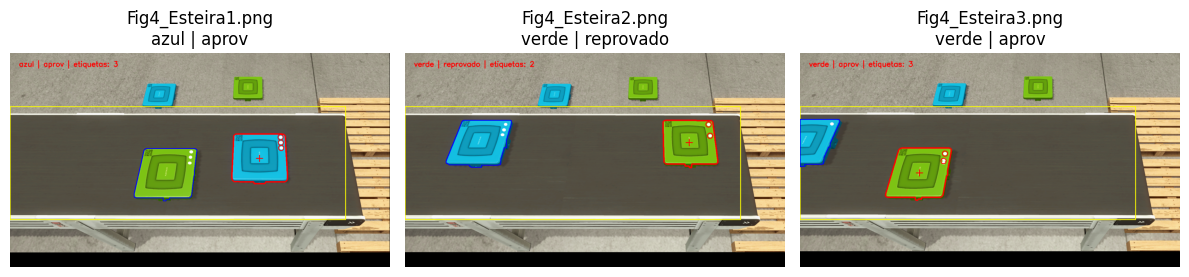

In [9]:
# ============================================================
# Exercício 4
# Posição, cor e aprovação da peça mais à direita
# ============================================================


# ============================================================
# 1) Definição da região da esteira
# ============================================================
# A câmera está fixa, então a esteira aparece sempre na mesma faixa da imagem.
# Usamos essa região para ignorar as peças que estão paradas no chão e os pallets.
#
# Nosso sistema de coordenadas da esteira será:
# - X = mesma coluna da imagem, pois a esteira começa encostada na esquerda;
# - Y = linha da imagem menos Y_TOPO_ESTEIRA.
# Assim, o topo da esteira vira Y = 0.
Y_TOPO_ESTEIRA = 180
Y_BASE_ESTEIRA = 560
X_DIREITA_ESTEIRA = 1130


# ============================================================
# 2) Função para criar uma máscara só da região da esteira
# ============================================================
def MascaraRegiaoEsteira(shape_img):

    h, w = shape_img[:2]

    mascara_roi = np.zeros((h, w), dtype=np.uint8)
    mascara_roi[Y_TOPO_ESTEIRA:Y_BASE_ESTEIRA, 0:X_DIREITA_ESTEIRA] = 1

    return mascara_roi


# ============================================================
# 3) Função para detectar as peças coloridas na esteira
# ============================================================
def DetectaPecasEsteira(img_rgb):

    R = img_rgb[:, :, 0]
    G = img_rgb[:, :, 1]
    B = img_rgb[:, :, 2]

    mascara_roi = MascaraRegiaoEsteira(img_rgb.shape)

    # Máscara azul:
    # a peça azul tem B alto, G também razoável e R baixo.
    mascara_azul = np.zeros_like(R, dtype=np.uint8)
    mascara_azul[(B > 120) & (G > 90) & (R < 80) & (mascara_roi == 1)] = 255

    # Máscara verde:
    # a peça verde tem G alto, enquanto R e B ficam mais baixos.
    mascara_verde = np.zeros_like(R, dtype=np.uint8)
    mascara_verde[(G > 110) & (R < 140) & (B < 90) & (mascara_roi == 1)] = 255

    mascaras = {
        "azul": mascara_azul,
        "verde": mascara_verde
    }

    pecas = []

    for cor in mascaras:

        mascara = mascaras[cor]

        # Fechamos falhas da peça com dilate e depois erode. Diz a aula que funciona.
        # Depois limpamos pontos s soltos com erode e depois dilate.
        
        kernel = np.ones((7, 7), np.uint8)
        mascara = cv2.dilate(mascara, kernel, iterations=2)
        mascara = cv2.erode(mascara, kernel, iterations=2)
        mascara = cv2.erode(mascara, kernel, iterations=1)
        mascara = cv2.dilate(mascara, kernel, iterations=1)

        contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for contorno in contornos:

            area = cv2.contourArea(contorno)

            # Peças reais são grandes.
            if area < 3000:
                continue

            M = cv2.moments(contorno)

            if M["m00"] == 0:
                continue

            # Centro da peça pelo momento do contorno.
            cx = M["m10"] / M["m00"]
            cy = M["m01"] / M["m00"]

            x, y, w, h = cv2.boundingRect(contorno)

            pecas.append({
                "cor": cor,
                "x_img": cx,
                "y_img": cy,
                "x_esteira": cx,
                "y_esteira": cy - Y_TOPO_ESTEIRA,
                "area": area,
                "bbox": (x, y, w, h),
                "contorno": contorno
            })

    return pecas


# ============================================================
# 4) Função para contar etiquetas brancas da peça escolhida
# ============================================================
def ContaEtiquetasBrancas(img_rgb, peca):

    x, y, w, h = peca["bbox"]

    # Recortamos uma região ao redor da peça.
    # Isso evita contar partes brancas da esteira ou do fundo.
    margem = 20
    x0 = max(0, x - margem)
    y0 = max(0, y - margem)
    x1 = min(img_rgb.shape[1], x + w + margem)
    y1 = min(img_rgb.shape[0], y + h + margem)

    recorte = img_rgb[y0:y1, x0:x1]

    R = recorte[:, :, 0]
    G = recorte[:, :, 1]
    B = recorte[:, :, 2]

    # Etiquetas brancas: R, G e B altos ao mesmo tempo.
    mascara_branco = np.zeros_like(R, dtype=np.uint8)
    mascara_branco[(R > 200) & (G > 200) & (B > 200)] = 255

    # Limpamos pixels brancos soltos com erode e depois dilate.
    kernel = np.ones((3, 3), np.uint8)
    mascara_branco = cv2.erode(mascara_branco, kernel, iterations=1)
    mascara_branco = cv2.dilate(mascara_branco, kernel, iterations=1)

    contornos, _ = cv2.findContours(mascara_branco, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    etiquetas = []
    total = 0

    for contorno in contornos:

        area = cv2.contourArea(contorno)

        # Uma etiqueta branca pequena fica nessa ordem de área pelo visto.
        if area < 20 or area > 300:
            continue

        (x_c, y_c), raio = cv2.minEnclosingCircle(contorno)
        circularidade = area / (np.pi * raio * raio)

        # As etiquetas são bolinhas brancas aproximadamente circulares.
        if circularidade < 0.45:
            continue

        # Em algumas imagens, duas etiquetas encostam e viram um único blob maior.
        # Por isso estimamos quantas etiquetas existem naquele blob pela área.
        quantidade_no_blob = int(round(area / 80))

        if quantidade_no_blob < 1:
            quantidade_no_blob = 1

        if quantidade_no_blob > 3:
            quantidade_no_blob = 3

        total += quantidade_no_blob

        etiquetas.append({
            "x": x_c + x0,
            "y": y_c + y0,
            "area": area,
            "qtd": quantidade_no_blob
        })

    return total, etiquetas


# ============================================================
# 5) Função principal da questão
# ============================================================
def AnalisaEsteira(caminho):

    img_bgr = cv2.imread(str(caminho))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    pecas = DetectaPecasEsteira(img_rgb)

    # A peça mais à direita é a que tem o maior centro X.
    peca_direita = max(pecas, key=lambda p: p["x_img"])

    n_etiquetas, etiquetas = ContaEtiquetasBrancas(img_rgb, peca_direita)

    if n_etiquetas >= 3:
        status = "aprov"
    else:
        status = "reprovado"

    return img_rgb, pecas, peca_direita, n_etiquetas, etiquetas, status


# ============================================================
# 6) Rodando nas três figuras
# ============================================================
caminhos_esteira = [
    Path("Figuras_APS3/Fig4_Esteira1.png"),
    Path("Figuras_APS3/Fig4_Esteira2.png"),
    Path("Figuras_APS3/Fig4_Esteira3.png")
]

plt.figure(figsize=(12, 5))

for i, caminho in enumerate(caminhos_esteira):

    img_rgb, pecas, peca_direita, n_etiquetas, etiquetas, status = AnalisaEsteira(caminho)

    img_saida = img_rgb.copy()

    # Desenhamos a ROI da esteira em amarelo para mostrar qual região foi usada.
    cv2.rectangle(img_saida, (0, Y_TOPO_ESTEIRA), (X_DIREITA_ESTEIRA, Y_BASE_ESTEIRA), (255, 255, 0), 2)

    # Contornos das peças encontradas.
    for peca in pecas:
        cv2.drawContours(img_saida, [peca["contorno"]], -1, (0, 0, 255), 2)

    # Peça selecionada, a mais à direita, em vermelho.
    cv2.drawContours(img_saida, [peca_direita["contorno"]], -1, (255, 0, 0), 3)

    cx = int(peca_direita["x_img"])
    cy = int(peca_direita["y_img"])
    cv2.drawMarker(img_saida, (cx, cy), (255, 0, 0), cv2.MARKER_CROSS, 22, 2)

    # Marcamos as etiquetas brancas encontradas.
    for etiqueta in etiquetas:
        cv2.circle(img_saida, (int(etiqueta["x"]), int(etiqueta["y"])), 9, (255, 0, 0), 2)

    texto = peca_direita["cor"] + " | " + status + " | etiquetas: " + str(n_etiquetas)
    cv2.putText(img_saida, texto, (30, 45), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

    print("\n", caminho.name)
    print("Peça mais à direita:")
    print("XY na imagem  = (%.1f, %.1f)" % (peca_direita["x_img"], peca_direita["y_img"]))
    print("XY na esteira = (%.1f, %.1f)" % (peca_direita["x_esteira"], peca_direita["y_esteira"]))
    print("Cor =", peca_direita["cor"])
    print("Etiquetas brancas =", n_etiquetas)
    print("Status =", status)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img_saida)
    plt.title(caminho.name + "\n" + peca_direita["cor"] + " | " + status)
    plt.axis("off")

plt.tight_layout()
plt.show()
